# Introduction to Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [11]:
sns.set_theme()

# Numerical Plots

- **Distribution**: Hist, KDE,Displot
- **Bar Plot**
- **Count Plot**
- **Facet Plot**: tạo ra một lưới 2D gồm các bảng được xác định bởi các biến tạo thành các hàng và cột.
- **Box Plot**: Phương pháp để mô tả bằng đồ thị các nhóm dữ liệu số thông qua các phần tư của chúng.
- **Join Plot**
- **Pair Plot**
- **Heat Map**: một kỹ thuật trực quan hóa dữ liệu cho thấy cường độ của một hiện tượng là màu sắc ở hai chiều

    # Distribution Plot

- Univariate distribution of observations

In [4]:
tips_df = sns.load_dataset('tips')

In [5]:
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


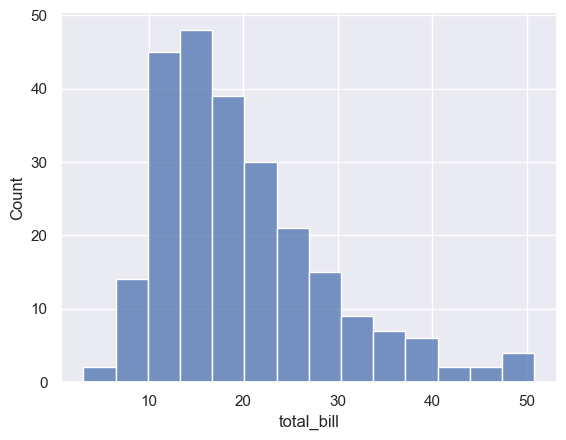

In [12]:
sns.histplot(data = tips_df["total_bill"]);

In [7]:
tips_df["total_bill"].value_counts().sort_values(ascending=False)

total_bill
13.42    3
10.34    2
21.01    2
10.33    2
17.92    2
        ..
29.03    1
27.18    1
22.67    1
17.82    1
18.78    1
Name: count, Length: 229, dtype: int64

# KDE Plot

- KDE Plot là phương pháp trực quan hóa phân phối dữ liệu tương tự Histogram.
- KDE biểu diễn dữ liệu bằng đường cong mật độ xác suất liên tục.

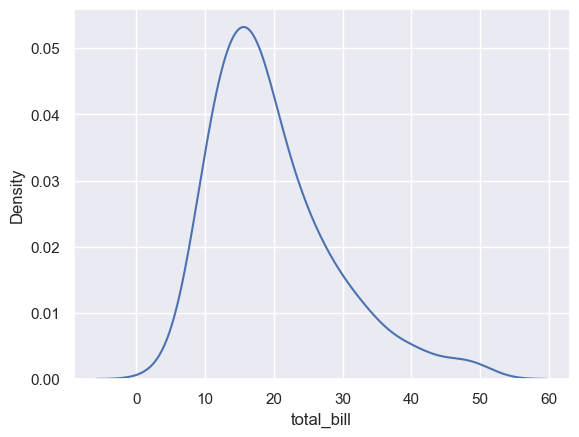

In [13]:
sns.kdeplot(data=tips_df["total_bill"]);

### Displot

* Tóm tắt phân phối dữ liệu

Phân tích thống kê yêu cầu hiểu về phân phối của các biến trong tập dữ liệu. 
Hàm `displot()` của seaborn hỗ trợ nhiều cách trực quan hóa phân phối dữ liệu, 
bao gồm Histogram và KDE (Kernel Density Estimation).

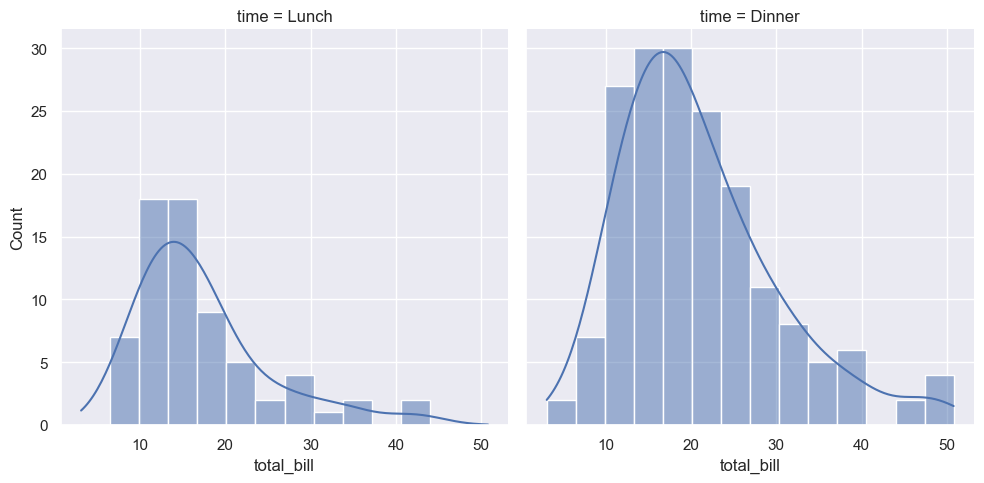

In [14]:
sns.displot(data=tips_df,x="total_bill",col = "time",kde = True);

### Categorical Plots
#### Bar Plots

In [16]:
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


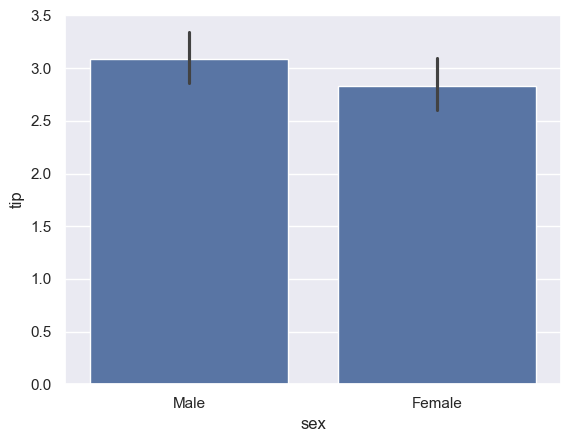

In [18]:
sns.barplot(data=tips_df,x="sex",y="tip",estimator=np.mean);

#### Count Plot

In [20]:
tips_df["sex"].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

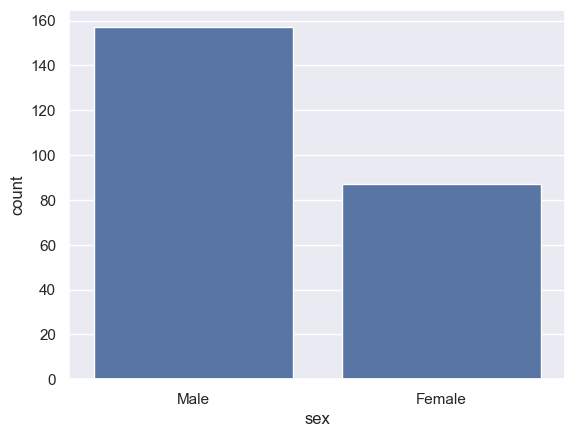

In [22]:
sns.countplot(data=tips_df,x = "sex");

## Box Plot

Box Plot cho biết dữ liệu được phân bố như thế nào 
("minimum", tứ phân vị thứ nhất (Q1), median, tứ phân vị thứ ba (Q3), và "maximum")

- Xác định outliers
- Kiểm tra dữ liệu có đối xứng không
- Xác định dữ liệu được nhóm chặt hay phân tán

Resource: https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51

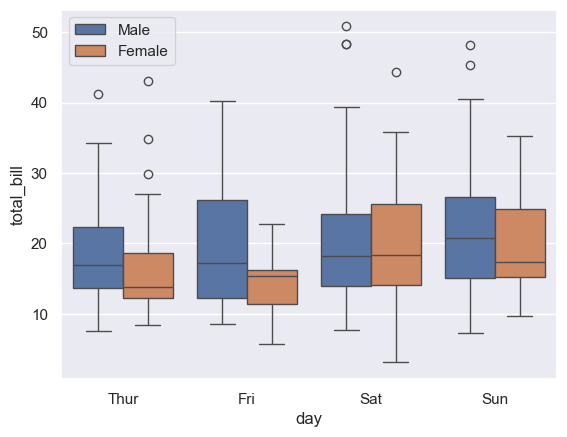

In [27]:
sns.boxplot(data=tips_df,x="day",y="total_bill",hue ="sex");
plt.legend(loc =0)

## Facet Grid

- FacetGrid có thể được vẽ với tối đa 3 chiều: `row`, `col`, và `hue`.
- Phương pháp chính để trực quan hóa dữ liệu trên lưới này là dùng `FacetGrid.map()`.

In [28]:
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


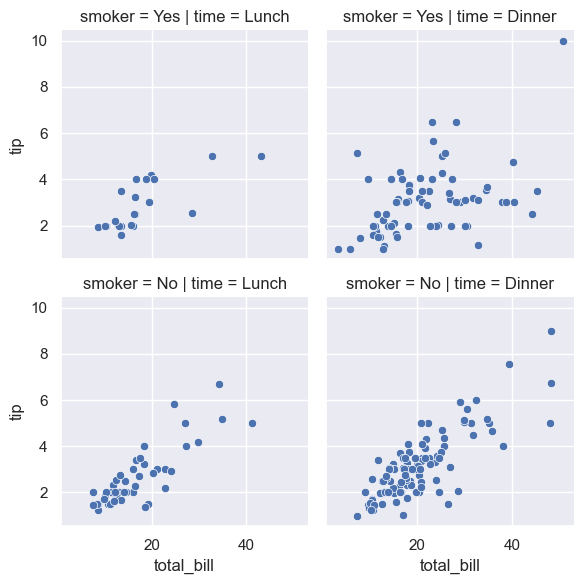

In [30]:
tips_fg = sns.FacetGrid(data=tips_df,row="smoker",col="time")
tips_fg.map(sns.scatterplot,'total_bill','tip');

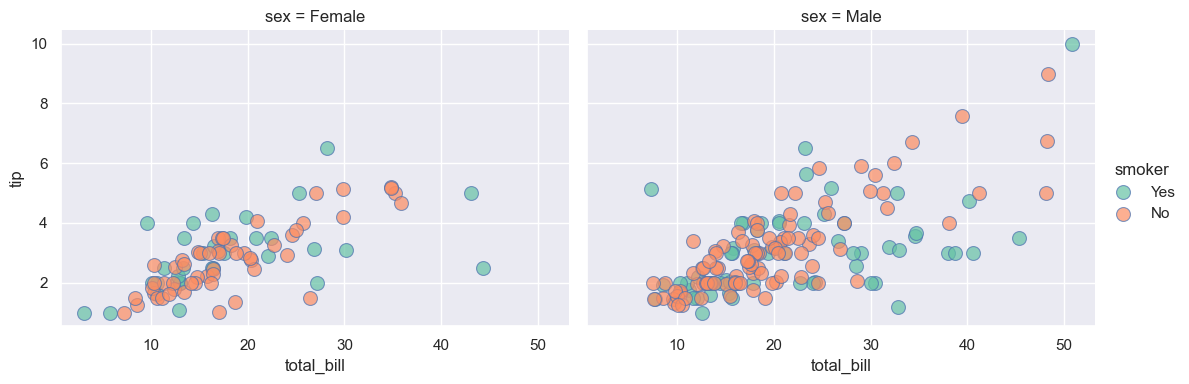

In [44]:
kws=dict(s=100,edgecolor='b',alpha=.7)
new_fg = sns.FacetGrid(data=tips_df,
                       col="sex",
                       hue="smoker",
                       col_order=["Female","Male"],
                       palette='Set2',
                       height=4,
                       aspect=1.4
                      )

new_fg.map(sns.scatterplot,'total_bill','tip',**kws);

new_fg.add_legend();